# Trace the Ace — Baseline Model Training and Optuna Tuning

This notebook trains multiple practical baseline classifiers using the
fully processed files created in the feature-engineering notebook.

## Workflow

1. Load all processed matrices
2. Train suitable models using basic configurations
3. Evaluate every model on the same untouched validation set
4. Rank models using validation Log Loss
5. Select the best baseline model automatically
6. Create an internal group-based tuning split
7. Tune only the winning model using Optuna
8. Evaluate the tuned model on the untouched validation set
9. Create a simple probability ensemble
10. Save models, predictions, scores, and reports

No feature processing or TF-IDF fitting is performed in this notebook.

In [2]:
from pathlib import Path
from time import perf_counter
import gc
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd

from scipy import sparse

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, ComplementNB, BernoulliNB
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score, brier_score_loss

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.5f}")


current_dir = Path.cwd().resolve()
search_locations = [current_dir, *current_dir.parents]

project_root = next((path for path in search_locations if (path / "Trace-The-Race-Dataset").is_dir()), None)

if project_root is None:
    raise FileNotFoundError("Trace-The-Race-Dataset folder was not found.")

dataset_root = project_root / "Trace-The-Race-Dataset"
feature_dir = dataset_root / "outputs" / "05_feature_engineering"
model_dir = dataset_root / "outputs" / "06_model_training"

baseline_model_dir = model_dir / "baseline_models"
tuned_model_dir = model_dir / "tuned_models"
optuna_dir = model_dir / "optuna"

for folder in [model_dir, baseline_model_dir, tuned_model_dir, optuna_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print("Feature folder :", feature_dir)
print("Model folder   :", model_dir)

Feature folder : C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\Trace-The-Race-Dataset\outputs\05_feature_engineering
Model folder   : C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\Trace-The-Race-Dataset\outputs\06_model_training


## 1. Load Processed Data

The feature-engineering notebook already created:

- Training and validation labels
- Response and session metadata
- Basic structured matrices
- Engineered structured matrices
- Word TF-IDF matrices
- Character TF-IDF matrices

Word and character matrices are horizontally combined without refitting
the TF-IDF vectorizers.

In [3]:
y_train = np.load(feature_dir / "train_labels.npy")
y_validation = np.load(feature_dir / "validation_labels.npy")

train_metadata = pd.read_parquet(feature_dir / "train_metadata.parquet")
validation_metadata = pd.read_parquet(feature_dir / "validation_metadata.parquet")

X_train_structured_basic = sparse.load_npz(feature_dir / "train_structured_basic.npz").tocsr()
X_validation_structured_basic = sparse.load_npz(feature_dir / "validation_structured_basic.npz").tocsr()

X_train_structured_engineered = sparse.load_npz(feature_dir / "train_structured_engineered.npz").tocsr()
X_validation_structured_engineered = sparse.load_npz(feature_dir / "validation_structured_engineered.npz").tocsr()

X_train_word = sparse.load_npz(feature_dir / "train_word_tfidf.npz").tocsr()
X_validation_word = sparse.load_npz(feature_dir / "validation_word_tfidf.npz").tocsr()

X_train_char = sparse.load_npz(feature_dir / "train_char_tfidf.npz").tocsr()
X_validation_char = sparse.load_npz(feature_dir / "validation_char_tfidf.npz").tocsr()


X_train_word_char = sparse.hstack([X_train_word, X_train_char], format="csr")
X_validation_word_char = sparse.hstack([X_validation_word, X_validation_char], format="csr")

X_train_all = sparse.hstack([X_train_structured_engineered, X_train_word, X_train_char], format="csr")
X_validation_all = sparse.hstack([X_validation_structured_engineered, X_validation_word, X_validation_char], format="csr")


X_train_structured_dense = X_train_structured_engineered.toarray().astype(np.float32)
X_validation_structured_dense = X_validation_structured_engineered.toarray().astype(np.float32)


train_matrices = {
    "structured_basic": X_train_structured_basic,
    "structured_engineered": X_train_structured_engineered,
    "structured_dense": X_train_structured_dense,
    "word": X_train_word,
    "char": X_train_char,
    "word_char": X_train_word_char,
    "all_features": X_train_all,
}

validation_matrices = {
    "structured_basic": X_validation_structured_basic,
    "structured_engineered": X_validation_structured_engineered,
    "structured_dense": X_validation_structured_dense,
    "word": X_validation_word,
    "char": X_validation_char,
    "word_char": X_validation_word_char,
    "all_features": X_validation_all,
}


matrix_summary = pd.DataFrame({
    "matrix": train_matrices.keys(),
    "train_shape": [str(matrix.shape) for matrix in train_matrices.values()],
    "validation_shape": [str(validation_matrices[name].shape) for name in train_matrices],
})

print("Training rows   :", f"{len(y_train):,}")
print("Validation rows :", f"{len(y_validation):,}")
print("Train rate      :", f"{y_train.mean():.5f}")
print("Validation rate :", f"{y_validation.mean():.5f}")

display(matrix_summary)

Training rows   : 28,125
Validation rows : 6,947
Train rate      : 0.69948
Validation rate : 0.71455


,matrix,train_shape,validation_shape
0,structured_basic,"(28125, 38)","(6947, 38)"
1,structured_engineered,"(28125, 43)","(6947, 43)"
2,structured_dense,"(28125, 43)","(6947, 43)"
3,word,"(28125, 60000)","(6947, 60000)"
4,char,"(28125, 60000)","(6947, 60000)"
5,word_char,"(28125, 120000)","(6947, 120000)"
6,all_features,"(28125, 120043)","(6947, 120043)"


## 2. Evaluation System

Every model is evaluated using the same validation set.

### Primary Metric

- Log Loss — lower is better

### Supporting Metrics

- ROC-AUC
- Accuracy
- Brier Score
- Training time
- Prediction time

Every model and its validation probability are saved immediately so that
a long notebook run can be resumed without losing completed experiments.

In [4]:
baseline_results = []
model_specs = {}

baseline_predictions = validation_metadata[["response_id", "session_id"]].copy()
baseline_predictions["correct"] = y_validation


def calculate_metrics(y_true, probability):
    probability = np.clip(np.asarray(probability), 1e-6, 1 - 1e-6)
    prediction = (probability >= 0.5).astype(np.int8)

    return {
        "log_loss": log_loss(y_true, probability),
        "roc_auc": roc_auc_score(y_true, probability),
        "accuracy": accuracy_score(y_true, prediction),
        "brier_score": brier_score_loss(y_true, probability),
    }


def run_baseline(model_key, model, matrix_key, family):
    X_train = train_matrices[matrix_key]
    X_validation = validation_matrices[matrix_key]

    print(f"\nTraining: {model_key}")

    start_train = perf_counter()

    try:
        model.fit(X_train, y_train)
        train_seconds = perf_counter() - start_train

        start_predict = perf_counter()
        probability = model.predict_proba(X_validation)[:, 1]
        prediction_seconds = perf_counter() - start_predict

        metrics = calculate_metrics(y_validation, probability)

        baseline_results.append({
            "model_key": model_key,
            "family": family,
            "matrix": matrix_key,
            **metrics,
            "train_seconds": train_seconds,
            "prediction_seconds": prediction_seconds,
            "status": "completed",
            "error": "",
        })

        baseline_predictions[f"{model_key}_probability"] = probability.astype(np.float32)
        model_specs[model_key] = {"family": family, "matrix": matrix_key}

        joblib.dump(model, baseline_model_dir / f"{model_key}.joblib")

        print("Log Loss :", f"{metrics['log_loss']:.6f}")
        print("ROC-AUC  :", f"{metrics['roc_auc']:.6f}")
        print("Accuracy :", f"{metrics['accuracy']:.6f}")
        print("Time     :", f"{train_seconds:.1f} seconds")

    except Exception as error:
        baseline_results.append({
            "model_key": model_key,
            "family": family,
            "matrix": matrix_key,
            "log_loss": np.nan,
            "roc_auc": np.nan,
            "accuracy": np.nan,
            "brier_score": np.nan,
            "train_seconds": perf_counter() - start_train,
            "prediction_seconds": np.nan,
            "status": "failed",
            "error": str(error),
        })

        print("Failed:", error)

    pd.DataFrame(baseline_results).to_csv(model_dir / "baseline_results_progress.csv", index=False)
    baseline_predictions.to_parquet(model_dir / "baseline_predictions_progress.parquet", index=False)

    gc.collect()

## 3. Reference and Structured Linear Baselines

The dummy model establishes the minimum reference score.

Two logistic-regression models are then trained:

- Basic structured features
- Engineered structured features

These models measure how much predictive information exists in the
session statistics without using transcript text.

In [5]:
run_baseline(
    model_key="dummy_prior",
    model=DummyClassifier(strategy="prior"),
    matrix_key="structured_basic",
    family="dummy",
)

run_baseline(
    model_key="structured_basic_logistic",
    model=LogisticRegression(solver="saga", max_iter=500, random_state=42, n_jobs=-1),
    matrix_key="structured_basic",
    family="logistic",
)

run_baseline(
    model_key="structured_engineered_logistic",
    model=LogisticRegression(solver="saga", max_iter=500, random_state=42, n_jobs=-1),
    matrix_key="structured_engineered",
    family="logistic",
)


Training: dummy_prior
Log Loss : 0.598570
ROC-AUC  : 0.500000
Accuracy : 0.714553
Time     : 0.0 seconds

Training: structured_basic_logistic
Log Loss : 0.592790
ROC-AUC  : 0.569404
Accuracy : 0.712970
Time     : 3.8 seconds

Training: structured_engineered_logistic
Log Loss : 0.592438
ROC-AUC  : 0.569905
Accuracy : 0.714265
Time     : 3.8 seconds


## 4. Structured Tree and Ensemble Models

Tree-based models are applied only to the low-dimensional structured
feature matrix.

They are not applied to the high-dimensional TF-IDF matrices.

The following models are compared:

- Decision Tree
- Random Forest
- Extra Trees
- Histogram Gradient Boosting
- Gradient Boosting
- AdaBoost
- Gaussian Naive Bayes

In [6]:
structured_models = [
    ("structured_decision_tree", DecisionTreeClassifier(random_state=42), "decision_tree"),
    ("structured_random_forest", RandomForestClassifier(random_state=42, n_jobs=-1), "random_forest"),
    ("structured_extra_trees", ExtraTreesClassifier(random_state=42, n_jobs=-1), "extra_trees"),
    ("structured_hist_gradient_boosting", HistGradientBoostingClassifier(random_state=42), "hist_gradient_boosting"),
    ("structured_gradient_boosting", GradientBoostingClassifier(random_state=42), "gradient_boosting"),
    ("structured_adaboost", AdaBoostClassifier(random_state=42), "adaboost"),
    ("structured_gaussian_nb", GaussianNB(), "gaussian_nb"),
]

for model_key, model, family in structured_models:
    run_baseline(model_key, model, "structured_dense", family)


Training: structured_decision_tree
Log Loss : 4.883525
ROC-AUC  : 0.524086
Accuracy : 0.607600
Time     : 0.8 seconds

Training: structured_random_forest
Log Loss : 0.604579
ROC-AUC  : 0.547946
Accuracy : 0.705196
Time     : 0.8 seconds

Training: structured_extra_trees
Log Loss : 0.609009
ROC-AUC  : 0.542332
Accuracy : 0.699439
Time     : 0.3 seconds

Training: structured_hist_gradient_boosting
Log Loss : 0.594714
ROC-AUC  : 0.557671
Accuracy : 0.714409
Time     : 1.9 seconds

Training: structured_gradient_boosting
Log Loss : 0.594630
ROC-AUC  : 0.558471
Accuracy : 0.712970
Time     : 12.6 seconds

Training: structured_adaboost
Log Loss : 0.598820
ROC-AUC  : 0.562663
Accuracy : 0.714265
Time     : 2.4 seconds

Training: structured_gaussian_nb
Log Loss : 0.735133
ROC-AUC  : 0.547650
Accuracy : 0.616525
Time     : 0.0 seconds


## 5. Word TF-IDF Baselines

The word-level TF-IDF matrix is evaluated using classifiers suitable for
large sparse matrices:

- Logistic Regression
- SGD Logistic Classifier
- Multinomial Naive Bayes
- Complement Naive Bayes
- Bernoulli Naive Bayes

In [7]:
word_models = [
    ("word_logistic", LogisticRegression(solver="saga", max_iter=500, random_state=42, n_jobs=-1), "logistic"),
    ("word_sgd", SGDClassifier(loss="log_loss", random_state=42, n_jobs=-1), "sgd"),
    ("word_multinomial_nb", MultinomialNB(), "multinomial_nb"),
    ("word_complement_nb", ComplementNB(), "complement_nb"),
    ("word_bernoulli_nb", BernoulliNB(), "bernoulli_nb"),
]

for model_key, model, family in word_models:
    run_baseline(model_key, model, "word", family)


Training: word_logistic
Log Loss : 0.545475
ROC-AUC  : 0.703621
Accuracy : 0.731251
Time     : 6.9 seconds

Training: word_sgd
Log Loss : 0.550447
ROC-AUC  : 0.701402
Accuracy : 0.726645
Time     : 1.2 seconds

Training: word_multinomial_nb
Log Loss : 0.611215
ROC-AUC  : 0.658732
Accuracy : 0.706492
Time     : 0.3 seconds

Training: word_complement_nb
Log Loss : 0.641106
ROC-AUC  : 0.658732
Accuracy : 0.654671
Time     : 0.2 seconds

Training: word_bernoulli_nb
Log Loss : 5.065784
ROC-AUC  : 0.624967
Accuracy : 0.591622
Time     : 0.5 seconds


## 6. Character TF-IDF Baselines

Character features capture spelling variation, equations, punctuation,
partial words, and local character patterns.

The following models are evaluated:

- Logistic Regression
- SGD Logistic Classifier
- Multinomial Naive Bayes
- Complement Naive Bayes

In [8]:
character_models = [
    ("char_logistic", LogisticRegression(solver="saga", max_iter=500, random_state=42, n_jobs=-1), "logistic"),
    ("char_sgd", SGDClassifier(loss="log_loss", random_state=42, n_jobs=-1), "sgd"),
    ("char_multinomial_nb", MultinomialNB(), "multinomial_nb"),
    ("char_complement_nb", ComplementNB(), "complement_nb"),
]

for model_key, model, family in character_models:
    run_baseline(model_key, model, "char", family)


Training: char_logistic
Log Loss : 0.555730
ROC-AUC  : 0.683821
Accuracy : 0.724773
Time     : 15.4 seconds

Training: char_sgd
Log Loss : 0.555494
ROC-AUC  : 0.686565
Accuracy : 0.722902
Time     : 2.3 seconds

Training: char_multinomial_nb
Log Loss : 0.684460
ROC-AUC  : 0.630497
Accuracy : 0.702030
Time     : 0.6 seconds

Training: char_complement_nb
Log Loss : 0.657802
ROC-AUC  : 0.630497
Accuracy : 0.667338
Time     : 0.5 seconds


## 7. Combined Text Baselines

Word and character TF-IDF matrices are combined without refitting either
vectorizer.

The combined sparse matrix is evaluated using:

- Logistic Regression
- SGD Logistic Classifier
- Complement Naive Bayes

In [9]:
combined_text_models = [
    ("word_char_logistic", LogisticRegression(solver="saga", max_iter=500, random_state=42, n_jobs=-1), "logistic"),
    ("word_char_sgd", SGDClassifier(loss="log_loss", random_state=42, n_jobs=-1), "sgd"),
    ("word_char_complement_nb", ComplementNB(), "complement_nb"),
]

for model_key, model, family in combined_text_models:
    run_baseline(model_key, model, "word_char", family)


Training: word_char_logistic
Log Loss : 0.550353
ROC-AUC  : 0.695117
Accuracy : 0.730099
Time     : 21.7 seconds

Training: word_char_sgd
Log Loss : 0.550718
ROC-AUC  : 0.698200
Accuracy : 0.730675
Time     : 3.7 seconds

Training: word_char_complement_nb
Failed: Unable to allocate 1.50 GiB for an array with shape (201969751,) and data type float64


## 8. All-Feature Baselines

The final combined matrix contains:

- Engineered structured features
- Word TF-IDF features
- Character TF-IDF features

Only scalable sparse linear models are used on this matrix.

In [10]:
all_feature_models = [
    ("all_features_logistic", LogisticRegression(solver="saga", max_iter=500, random_state=42, n_jobs=-1), "logistic"),
    ("all_features_sgd", SGDClassifier(loss="log_loss", random_state=42, n_jobs=-1), "sgd"),
]

for model_key, model, family in all_feature_models:
    run_baseline(model_key, model, "all_features", family)


Training: all_features_logistic
Log Loss : 0.550757
ROC-AUC  : 0.695039
Accuracy : 0.730819
Time     : 510.2 seconds

Training: all_features_sgd
Log Loss : 0.558205
ROC-AUC  : 0.687903
Accuracy : 0.723910
Time     : 9.2 seconds


## 9. Baseline Model Comparison

All completed models are ranked by validation Log Loss.

The lowest Log Loss represents the strongest probability baseline.

Failed models remain in the saved results table but are excluded from
ranking.

,model_key,family,matrix,log_loss,roc_auc,accuracy,brier_score,train_seconds
0,word_logistic,logistic,word,0.54547,0.70362,0.73125,0.18249,6.90546
1,word_char_logistic,logistic,word_char,0.55035,0.69512,0.73010,0.18444,21.66760
2,word_sgd,sgd,word,0.55045,0.70140,0.72664,0.18441,1.15017
3,word_char_sgd,sgd,word_char,0.55072,0.69820,0.73068,0.18454,3.71339
4,all_features_logistic,logistic,all_features,0.55076,0.69504,0.73082,0.18452,510.17019
5,char_sgd,sgd,char,0.55549,0.68657,0.72290,0.18671,2.34723
6,char_logistic,logistic,char,0.55573,0.68382,0.72477,0.18680,15.38567
7,all_features_sgd,sgd,all_features,0.55820,0.68790,0.72391,0.18781,9.24962
8,structured_engineered_logistic,logistic,structured_engineered,0.59244,0.56991,0.71427,0.20176,3.76465
9,structured_basic_logistic,logistic,structured_basic,0.59279,0.56940,0.71297,0.20195,3.75335


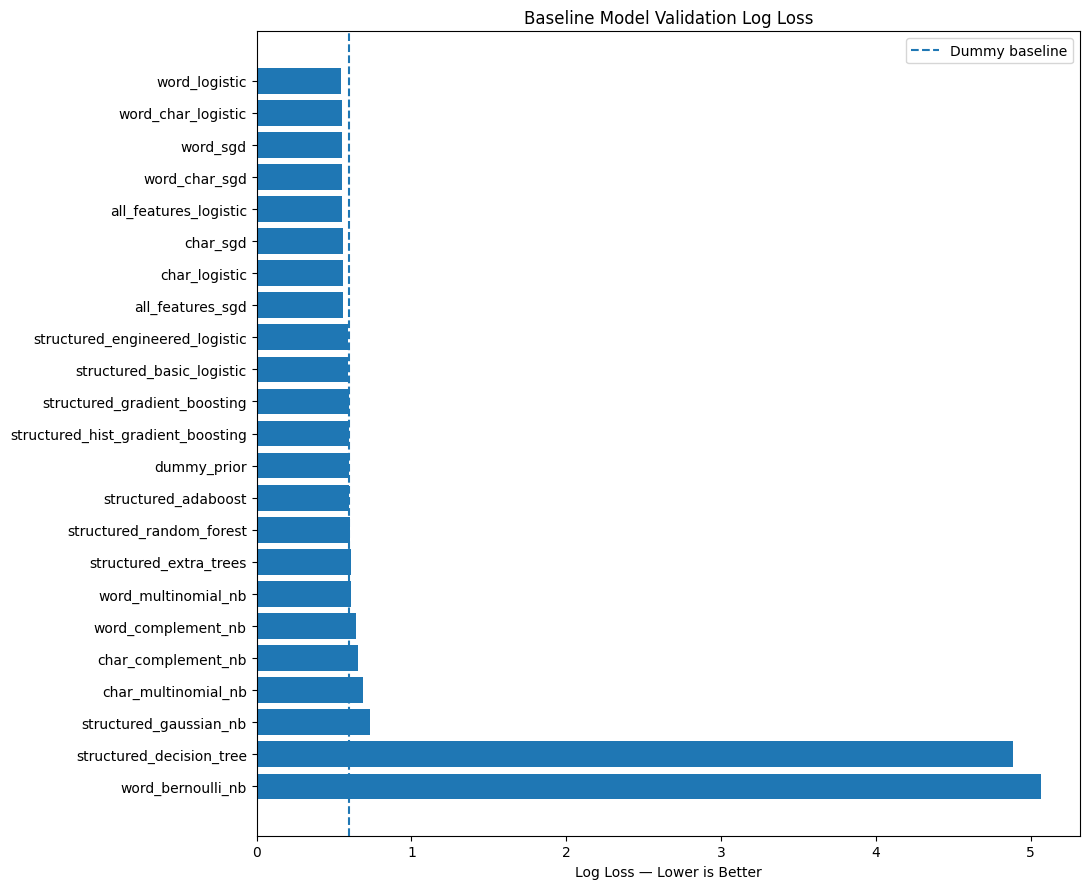

In [11]:
baseline_results_df = pd.DataFrame(baseline_results)

completed_results = (
    baseline_results_df[baseline_results_df["status"] == "completed"]
    .sort_values("log_loss")
    .reset_index(drop=True)
)

baseline_results_df.to_csv(model_dir / "baseline_results.csv", index=False)
baseline_predictions.to_parquet(model_dir / "baseline_predictions.parquet", index=False)

display(
    completed_results[
        [
            "model_key",
            "family",
            "matrix",
            "log_loss",
            "roc_auc",
            "accuracy",
            "brier_score",
            "train_seconds",
        ]
    ]
)


plt.figure(figsize=(11, 9))
plot_data = completed_results.sort_values("log_loss", ascending=False)

plt.barh(plot_data["model_key"], plot_data["log_loss"])
plt.axvline(completed_results.loc[completed_results["model_key"] == "dummy_prior", "log_loss"].iloc[0], linestyle="--", label="Dummy baseline")
plt.title("Baseline Model Validation Log Loss")
plt.xlabel("Log Loss — Lower is Better")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Select the Best Baseline Model

The best non-dummy model is selected automatically using validation
Log Loss.

Its model family and feature matrix determine the Optuna search space.

In [12]:
tuning_candidates = completed_results[completed_results["family"] != "dummy"].copy()
best_baseline_row = tuning_candidates.iloc[0]

best_model_key = best_baseline_row["model_key"]
best_family = model_specs[best_model_key]["family"]
best_matrix_key = model_specs[best_model_key]["matrix"]

selected_model_info = {
    "model_key": best_model_key,
    "family": best_family,
    "matrix": best_matrix_key,
    "baseline_log_loss": float(best_baseline_row["log_loss"]),
    "baseline_roc_auc": float(best_baseline_row["roc_auc"]),
}

with open(model_dir / "selected_baseline_model.json", "w", encoding="utf-8") as file:
    json.dump(selected_model_info, file, indent=2)

print("Selected model :", best_model_key)
print("Family         :", best_family)
print("Matrix         :", best_matrix_key)
print("Log Loss       :", f"{best_baseline_row['log_loss']:.6f}")

Selected model : word_logistic
Family         : logistic
Matrix         : word
Log Loss       : 0.545475


In [1]:
import sys
from importlib.metadata import PackageNotFoundError, version

import sklearn


print("Python version      :", sys.version.split()[0])
print("Python executable   :", sys.executable)
print("Scikit-learn version:", sklearn.__version__)

for package_name in ["optuna", "psutil"]:
    try:
        print(f"{package_name:<19}:", version(package_name))
    except PackageNotFoundError:
        print(f"{package_name:<19}: NOT INSTALLED")

Python version      : 3.10.20
Python executable   : c:\Users\USER\miniconda3\envs\ml_project\python.exe
Scikit-learn version: 1.7.2
optuna             : 4.9.0
psutil             : 7.2.2


In [4]:
%pip install -U optuna psutil

  Attempting uninstall: optuna
    Found existing installation: optuna 4.8.0
    Uninstalling optuna-4.8.0:
      Successfully uninstalled optuna-4.8.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
import optuna
import psutil
import sklearn

print("Environment ready.")
print("Scikit-learn:", sklearn.__version__)
print("Optuna      :", optuna.__version__)
print("CPU threads :", psutil.cpu_count(logical=True))
print("RAM         :", f"{psutil.virtual_memory().total / 1024**3:.1f} GB")

Environment ready.
Scikit-learn: 1.7.2
Optuna      : 4.9.0
CPU threads : 16
RAM         : 31.6 GB
